In [2]:
import numpy, pandas, conntility, connalysis

from pathlib import Path
from matplotlib import pyplot as plt
from scipy.spatial import distance

root = Path("/Users/mwr/Documents/artefacts/connectomes/Human connectivity paper")
root = Path("/Users/mwr/Documents/artefacts/connectomes")

dataset = "mouse_em"

# Load the data
if dataset == "human_model":
    fn = root / "Human_NEWfunct_conmat_filtered_compressed.h5"
    M = conntility.ConnectivityMatrix.from_h5(fn)
elif dataset == "human_em":
    fn = root / "Shapson_Coe_et_al_human_all_somas.h5"
    M = conntility.ConnectivityMatrix.from_h5(fn, "compressed")
elif dataset == "mouse_em":
    fn = root / "microns_mm3_connectome_v1181.h5"
    M = conntility.ConnectivityMatrix.from_h5(fn, "condensed")
elif dataset == "rat_model":
    fn = root / "Rat_pruned_E_to_E_conmat.h5"
    M = conntility.ConnectivityMatrix.from_h5(fn)

In [3]:
if dataset == "human_em":
    # Shapson-Coe

    # STEP 1: Only neurons. Filter out non-neurons
    types_of_interest = [
        "PYRAMIDAL",
        "INTERNEURON",
        "SPINY_ATYPICAL",
        "UNCLASSIFIED_NEURON",
        "SPINY_STELLATE"
    ]
    M = M.index("celltype").isin(types_of_interest)

    # STEP 2: Convert from voxel indices to coordinates in um
    xyz = ["x", "y", "z"]
    full_res = numpy.array([ 8, 8, 33 ]) # voxel resultion in nm

    for _col, _fac in zip(xyz, full_res):
        M.add_vertex_property(_col + "_um", M.vertices[_col].values * _fac / 1000)
    xyz = ["x_um", "y_um", "z_um"]

    # STEP 4: Only layer 2/3
    M = M.index("layer").isin(["Layer 2", "Layer 3"])

    # Dataset already is a slice. With x and y as main coordinates and z the 200 um slice thickness
    xy_slice = ["x_um", "y_um"]

if dataset == "human_model":
    # HUMAN MODEL
    # STEP 1: Only layers 2/3.
    types_of_interest = [
        "L2_PTPC",
        "L3_PTPC",
        "L3_STPC",
        "L3_PC"
    ]
    M = M.index("mtype").isin(types_of_interest)
    # STEP 2:Create slice
    M = M.slice(0.0, 0.0, 150.0, columns_slice=["x", "z"], column_y="y")
    xyz = ["x", "y", "z"]
    xy_slice = ["slice_x", "slice_y"]

if dataset == "mouse_em":
    # STEP 1: Only layers 2/3.
    types_of_interest = ["L2a", "L2b", "L2c", "L3a", "L3b"]
    M = M.index("cell_type").isin(types_of_interest)
    # STEP 2: Convert coordinates from nm to um
    for _coord in ["x", "y", "z"]:
        M.add_vertex_property(_coord, M.vertices[_coord + "_nm"].values / 1000)
    # STEP 3:Create slice
    # In Microns the y-axis is sufficently close to vertical.
    M = M.slice(0.0, 0.0, 150.0, columns_slice=["x", "z"], column_y="y")
    
    xy_slice = ["slice_x", "slice_y"]

if dataset == "rat_model":
    # HUMAN MODEL
    # STEP 1: Only EXC and only layers 2/3.
    M = M.index("synapse_class").eq("EXC")
    M = M.index("layer").isin(["2", "3"])
    # STEP 2:Create slice
    M = M.slice(0.0, 0.0, 150.0, columns_slice=["x", "z"], column_y="y")
    xyz = ["x", "y", "z"]
    xy_slice = ["slice_x", "slice_y"]

In [4]:
R = M.to_reciprocal()

In [5]:
D = distance.squareform(distance.pdist(M.vertices[xy_slice]))
dbins = numpy.arange(0, 550, 50)
dbins[0] = 1E-9
D = numpy.digitize(D, bins=dbins) - 1

A = numpy.array(M.matrix.astype(bool).todense())
Ar = numpy.array(R.matrix.astype(bool).todense())

In [6]:
mdl = connalysis.modelling.conn_prob_2nd_order_model(M.matrix.tocsc().astype(bool), M.vertices, coord_names=xy_slice)

Ctrl = connalysis.randomization.run_DD2_model(M.matrix, M.vertices, model_params_dd2=mdl, coord_names=xy_slice)
Ctrl = conntility.ConnectivityMatrix(Ctrl, vertex_properties=M._vertex_properties)
Ctrl_r = Ctrl.to_reciprocal()

Cr = numpy.array(Ctrl_r.matrix.astype(bool).todense())

Dtrl = connalysis.randomization.ER_model(M.matrix)
Dtrl = conntility.ConnectivityMatrix(Dtrl, vertex_properties=M._vertex_properties)
Dtrl_r = Dtrl.to_reciprocal()

Dr = numpy.array(Dtrl_r.matrix.astype(bool).todense())

[2025-05-23 14:18:44,220] INFO: Running order-2 model building {'coord_names': ['slice_x', 'slice_y'], 'model_dir': None, 'data_dir': None, 'plot_dir': None, 'do_plot': False, 'part_idx': None, 'sample_seed': None}...
[2025-05-23 14:18:44,346] INFO: Extracting 1-dimensional (14) connection probabilities...


[2025-05-23 14:18:46,274] INFO: MODEL FIT: f(x) = 0.041546 * exp(-0.014510 * x)
[2025-05-23 14:18:46,276] INFO: Run DD2 model with parameters: 
      exp_model_scale  exp_model_exponent
seed                                     
None         0.041546             0.01451


In [7]:
n_con = numpy.array([A[D == i].sum() for i in range(len(dbins))])
n_rec = numpy.array([Ar[D == i].sum() for i in range(len(dbins))])
n_pair = numpy.array([(D == i).sum() for i in range(len(dbins))])

c_rec = numpy.array([Cr[D == i].sum() for i in range(len(dbins))])
d_rec = numpy.array([Dr[D == i].sum() for i in range(len(dbins))])

In [8]:
compare_to = "DD"

/var/folders/py/wqmt8l2s5zb8fhrxbd_b258w0000gn/T/ipykernel_24812/454780077.py:16: RuntimeWarning: invalid value encountered in divide
  plt.plot(bin_c, (n_rec[:-1] - cmp[:-1]) / (n_rec[:-1] + cmp[:-1]))


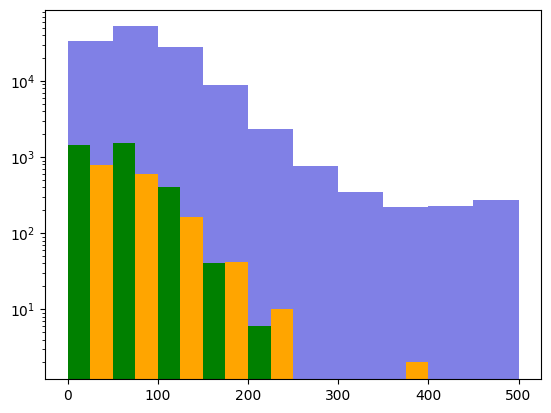

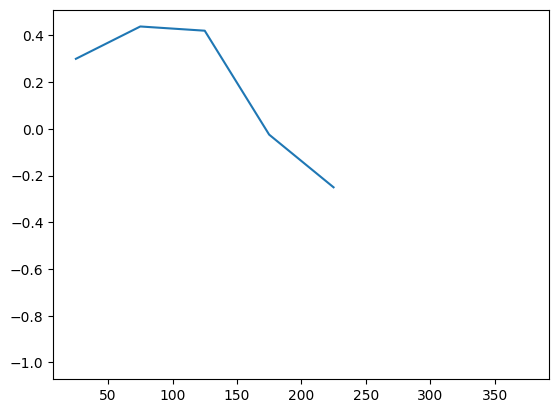

In [9]:
bin_c = 0.5 * (dbins[:-1] + dbins[1:])
bin_w = numpy.mean(numpy.diff(dbins))

if compare_to == "ER":
    cmp = d_rec
elif compare_to == "DD":
    cmp = c_rec

plt.bar(bin_c, n_con[:-1], width=bin_w, color=[0.5, 0.5, 0.9])
plt.bar(bin_c - 0.25 * bin_w, n_rec[:-1], width=0.5 * bin_w, color="green")
plt.bar(bin_c + 0.25 * bin_w, cmp[:-1], width=0.5 * bin_w, color="orange")

plt.gca().set_yscale('log')

plt.figure()
plt.plot(bin_c, (n_rec[:-1] - cmp[:-1]) / (n_rec[:-1] + cmp[:-1]))
